# CS 282
### Programming Assignment 3

Jan Lendl R. Uy

2019-00312

#### Sytem Specifications
- macOS Sequoia 15.0.1
- Macbook Air M1 (ARM), 8-Core CPU and 8-Core GPU

In [1]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'

[notice] A new release of pip available: 22.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

### Step 1
Load the image pair library1_camera, library2_camera and matching points file library_matches.txt.

In [3]:
library_1 = cv2.imread("epipairs/library1.jpg")
library_2 = cv2.imread("epipairs/library2.jpg")

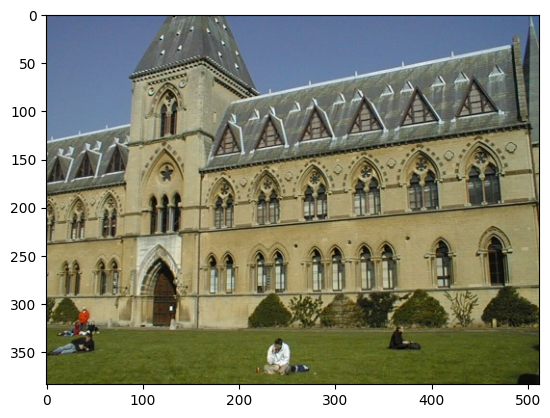

In [4]:
plt.imshow(cv2.cvtColor(library_1, cv2.COLOR_BGR2RGB))

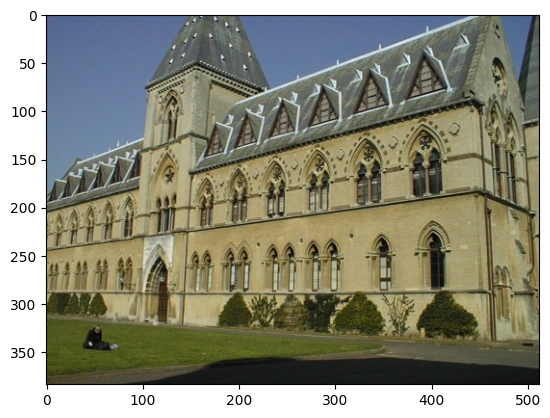

In [5]:
plt.imshow(cv2.cvtColor(library_2, cv2.COLOR_BGR2RGB))

In [6]:
matches = np.loadtxt("epipairs/library_matches.txt", dtype=np.float32)

### Step 2
Fit a fundamental matrix to the matching points. There is no need to use RANSAC here since all the
matches are correct. Report the residual, which should be the mean squared distance (in pixels) between points in the second image and the corresponding epipolar lines.

In [7]:
library_1_points = np.float32(matches[:, 0:2])
library_2_points = np.float32(matches[:, 2:4])

In [8]:
F, mask = cv2.findFundamentalMat(library_1_points, library_2_points, cv2.FM_LMEDS)
print(f"Fundamental matrix:\n{F}")

Fundamental matrix:
[[ 4.44901892e-06 -5.92188784e-05  5.50374909e-03]
 [ 6.44240710e-05 -2.20949736e-06 -5.12744636e-02]
 [-1.06503169e-02  4.91904308e-02  1.00000000e+00]]


In [9]:
def compute_residual(points, lines):
    residuals = []
    for i in range(len(points)):
        point = points[i]
        line = lines[i]
        residual = np.abs(line[0, 0] * point[0] + line[0, 1] * point[1] + line[0, 2])/np.sqrt(line[0, 0]**2 + line[0, 1]**2)
        residuals.append(residual)

    mean_residual = np.mean(np.square(residuals))
    
    return mean_residual

In [10]:
# Function to draw epipolar lines (for visualization)
def draw_epipolar_lines(img1, img2, pts1, pts2, F, sample_size=20):
    """Draw epipolar lines and points for visualization"""
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    # Create RGB versions of the images
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    
    # Sample points if there are too many
    if len(pts1) > sample_size:
        indices = np.random.choice(len(pts1), sample_size, replace=False)
        sample_pts1 = pts1[indices]
        sample_pts2 = pts2[indices]
    else:
        sample_pts1 = pts1
        sample_pts2 = pts2
    
    # Compute epipolar lines in the second image
    lines2 = cv2.computeCorrespondEpilines(sample_pts1.reshape(-1, 1, 2), 1, F)
    lines2 = lines2.reshape(-1, 3)
    
    # Compute epipolar lines in the first image
    lines1 = cv2.computeCorrespondEpilines(sample_pts2.reshape(-1, 1, 2), 2, F)
    lines1 = lines1.reshape(-1, 3)
    
    # Create images with epipolar lines
    img1_lines = img1_rgb.copy()
    img2_lines = img2_rgb.copy()
    
    # Draw epipolar lines and points in the second image
    for i, (pt, line) in enumerate(zip(sample_pts2, lines2)):
        color = np.random.randint(0, 255, 3).tolist()
        x0, y0 = 0, int(-(line[2]) / line[1])
        x1, y1 = w2, int(-(line[2] + line[0] * w2) / line[1])
        
        img2_lines = cv2.line(img2_lines, (x0, y0), (x1, y1), color, 1)
        img2_lines = cv2.circle(img2_lines, (int(pt[0]), int(pt[1])), 5, color, -1)
    
    # Draw epipolar lines and points in the first image
    for i, (pt, line) in enumerate(zip(sample_pts1, lines1)):
        color = np.random.randint(0, 255, 3).tolist()
        x0, y0 = 0, int(-(line[2]) / line[1])
        x1, y1 = w1, int(-(line[2] + line[0] * w1) / line[1])
        
        img1_lines = cv2.line(img1_lines, (x0, y0), (x1, y1), color, 1)
        img1_lines = cv2.circle(img1_lines, (int(pt[0]), int(pt[1])), 5, color, -1)
    
    # Display the images side by side
    plt.figure(figsize=(16, 8))
    plt.subplot(121)
    plt.imshow(img1_lines)
    plt.title("Image 1 with epipolar lines")
    
    plt.subplot(122)
    plt.imshow(img2_lines)
    plt.title("Image 2 with epipolar lines")
    
    plt.tight_layout()
    plt.show()

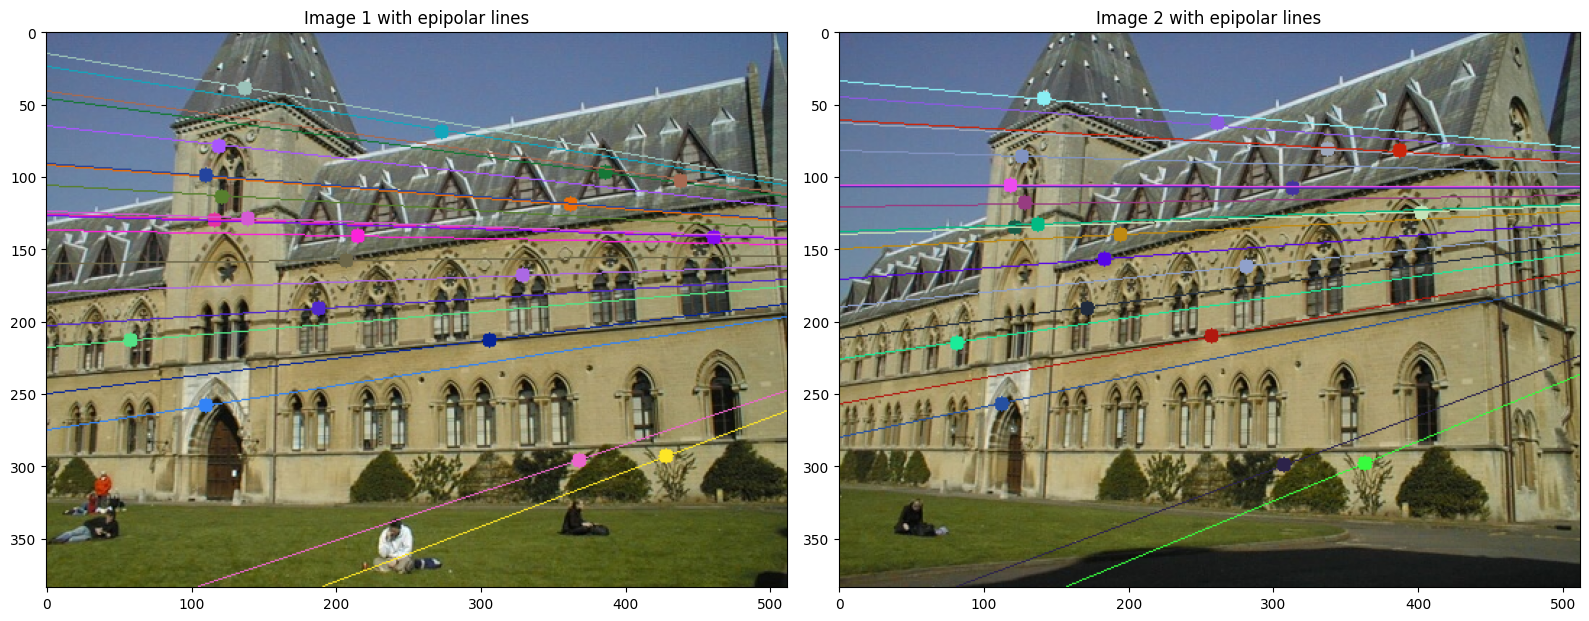

In [11]:
# Visualize epipolar lines
draw_epipolar_lines(library_1, library_2, library_1_points, library_2_points, F)

In [12]:
epipolar_lines_1 = cv2.computeCorrespondEpilines(library_2_points.reshape(-1, 1, 2), 2, F)

mean_residual = compute_residual(library_1_points, epipolar_lines_1)
print(f"Residual = {mean_residual}")

Residual = 0.1619260013103485


### Step 3
Now fit a fundamental matrix based on putative correspondences obtained by your code from Program-
ming Assignment 2. Because the set of putative matches includes outliers, you will need to use RANSAC. For this part, use only the normalized fitting approach.

In [13]:
# Compute fundamental matrix with RANSAC
F_ransac, mask_ransac = cv2.findFundamentalMat(library_1_points, library_2_points, cv2.FM_RANSAC, 1.0, 0.99)

# Get inlier points
inlier_pts1 = library_1_points[mask_ransac.ravel() == 1]
inlier_pts2 = library_2_points[mask_ransac.ravel() == 1]

# Calculate residual for RANSAC method
epipolar_lines_1_ransac = cv2.computeCorrespondEpilines(library_2_points.reshape(-1, 1, 2), 2, F_ransac)
residual_ransac = compute_residual(inlier_pts2, epipolar_lines_1_ransac)
print(f"Residual from RANSAC = {mean_residual}")

Residual from RANSAC = 0.1619260013103485


### Step 4
Load the camera matrices for the two images (they are stored as 3x4 matrices in the files
library1 camera.txt and library2 camera.txt). Find the centers of the two cameras. Use
linear least squares to triangulate the position of each matching pair of points given the two cameras. Display the two camera centers and scene matches in 3D. Also compute the residuals between the observed 2D points and the projected 3D points in the two images.

In [14]:
library_1_camera = np.loadtxt("epipairs/library1_camera.txt")
library_2_camera = np.loadtxt("epipairs/library2_camera.txt")

In [15]:
# Find the camera center from the camera matrix P
# The camera center is the null space of P
def find_camera_center(P):
    # Use SVD to find the null space
    U, S, Vt = np.linalg.svd(P)
    
    # The camera center is the last row of Vt (transposed)
    C_homogeneous = Vt[-1, :]
    
    # Convert from homogeneous coordinates
    C = C_homogeneous[:3] / C_homogeneous[3]
    
    return C

In [16]:
library_1_center = find_camera_center(library_1_camera)
library_2_center = find_camera_center(library_2_camera)

print(f"Camera 1 Center: {library_1_center}")
print(f"Camera 2 Center: {library_2_center}")

Camera 1 Center: [  7.28863053 -21.52118112  17.73503585]
Camera 2 Center: [  6.89405488 -15.39232716  23.41498687]


In [17]:
# Triangulate the 3D points
points_4d_homogeneous = cv2.triangulatePoints(library_1_camera, 
                                              library_2_camera,
                                              library_1_points.T, 
                                              library_2_points.T)

# Convert from homogeneous coordinates to 3D coordinates
points_3d = points_4d_homogeneous[:3, :] / points_4d_homogeneous[3, :]
points_3d = points_3d.T

In [18]:
# Function to calculate reprojection error
def calculate_reprojection_error(P, points_3d, points_2d):
    """Calculate the reprojection error between projected 3D points and original 2D points"""
    # Convert 3D points to homogeneous coordinates
    points_homogeneous = np.hstack((points_3d, np.ones((points_3d.shape[0], 1))))
    
    # Project 3D points back to 2D
    projected_points = np.dot(P, points_homogeneous.T).T
    projected_points = projected_points[:, :2] / projected_points[:, 2:]
    
    # Calculate Euclidean distance between original and projected points
    errors = np.sqrt(np.sum((projected_points - points_2d)**2, axis=1))
    return errors

# Calculate reprojection errors
reprojection_error1 = calculate_reprojection_error(library_1_camera, points_3d, library_1_points)
reprojection_error2 = calculate_reprojection_error(library_2_camera, points_3d, library_2_points)

print(f"Mean reprojection error in image 1: {np.mean(reprojection_error1):.6f} pixels")
print(f"Mean reprojection error in image 2: {np.mean(reprojection_error2):.6f} pixels")

Mean reprojection error in image 1: 0.079812 pixels
Mean reprojection error in image 2: 0.092716 pixels


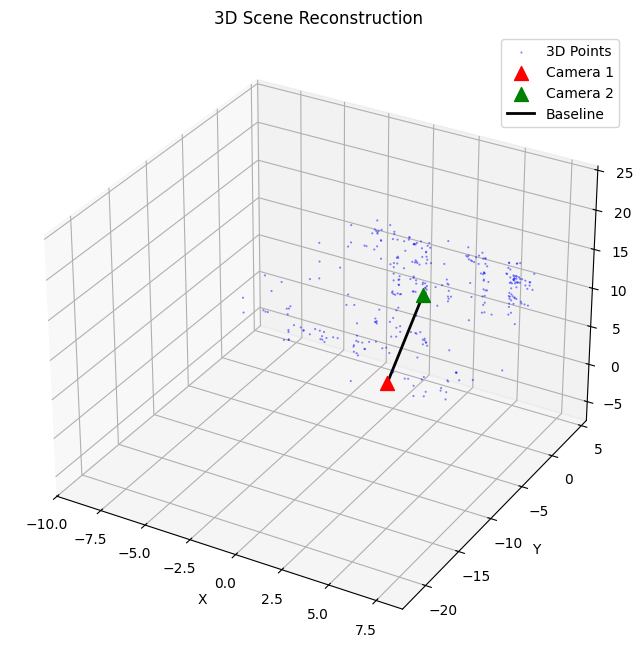

In [19]:
# Visualize the 3D points and camera centers
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot a sample of 3D points if there are many
max_points_to_plot = 1000
if len(points_3d) > max_points_to_plot:
    indices = np.random.choice(len(points_3d), max_points_to_plot, replace=False)
    sample_points = points_3d[indices]
    ax.scatter(sample_points[:, 0], sample_points[:, 1], sample_points[:, 2], 
               c="blue", marker=".", s=1, alpha=0.5, label="3D Points (sample)")
else:
    ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], 
               c="blue", marker=".", s=1, alpha=0.5, label="3D Points")

# Plot camera centers
ax.scatter(library_1_center[0], library_1_center[1], library_1_center[2], c="red", marker="^", s=100, label="Camera 1")
ax.scatter(library_2_center[0], library_2_center[1], library_2_center[2], c="green", marker="^", s=100, label="Camera 2")

# Connect camera centers (baseline)
ax.plot([library_1_center[0], library_2_center[0]], [library_1_center[1], library_2_center[1]], [library_1_center[2], library_2_center[2]], 
         "k-", linewidth=2, label="Baseline")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Scene Reconstruction")
ax.legend()

plt.show()

### Step 5
Apply triangulation to inlier matches that you obtained in step 3 above.

In [20]:
# Triangulate inlier points
inlier_points_4d = cv2.triangulatePoints(library_1_camera, library_2_camera, inlier_pts1.T, inlier_pts2.T)
inlier_points_3d = inlier_points_4d[:3, :] / inlier_points_4d[3, :]
inlier_points_3d = inlier_points_3d.T

# Calculate reprojection errors for inliers
inlier_error1 = calculate_reprojection_error(library_1_camera, inlier_points_3d, inlier_pts1)
inlier_error2 = calculate_reprojection_error(library_2_camera, inlier_points_3d, inlier_pts2)

print(f"Mean reprojection error for inliers in image 1: {np.mean(inlier_error1):.6f} pixels")
print(f"Mean reprojection error for inliers in image 2: {np.mean(inlier_error2):.6f} pixels")

Mean reprojection error for inliers in image 1: 0.074430 pixels
Mean reprojection error for inliers in image 2: 0.086928 pixels


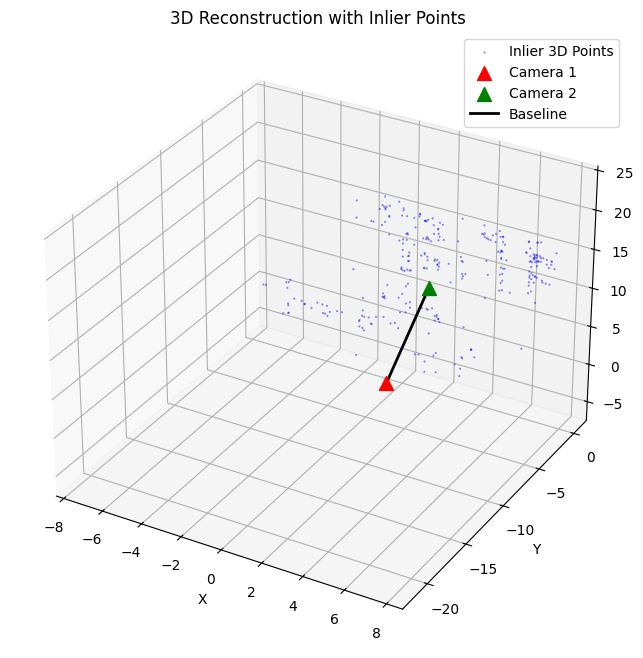

In [21]:
# Visualize the inlier 3D points and camera centers
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot inlier 3D points
if len(inlier_points_3d) > max_points_to_plot:
    indices = np.random.choice(len(inlier_points_3d), max_points_to_plot, replace=False)
    sample_inliers = inlier_points_3d[indices]
    ax.scatter(sample_inliers[:, 0], sample_inliers[:, 1], sample_inliers[:, 2], 
               c="blue", marker=".", s=1, alpha=0.5, label="Inlier 3D Points (sample)")
else:
    ax.scatter(inlier_points_3d[:, 0], inlier_points_3d[:, 1], inlier_points_3d[:, 2], 
               c="blue", marker=".", s=1, alpha=0.5, label="Inlier 3D Points")

# Plot camera centers
ax.scatter(library_1_center[0], library_1_center[1], library_1_center[2], c="red", marker="^", s=100, label="Camera 1")
ax.scatter(library_2_center[0], library_2_center[1], library_2_center[2], c="green", marker="^", s=100, label="Camera 2")

# Connect camera centers
ax.plot([library_1_center[0], library_2_center[0]], [library_1_center[1], library_2_center[1]], [library_1_center[2], library_2_center[2]], 
         "k-", linewidth=2, label="Baseline")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Reconstruction with Inlier Points")
ax.legend()

plt.show()